# Output Metrics Data Analysis

This notebook analyzes the output metrics produced from the BBQ disambiguated evaluation runs.

The analysis is based on the summary CSV files generated by the evaluation pipeline:

- `global_metrics_by_run.csv`
- `global_metrics_summary.csv`
- `category_metrics_by_run.csv`
- `category_metrics_summary.csv`
- `prediction_type_distribution_by_run.csv`
- `prediction_type_distribution_summary.csv`
- `prediction_type_distribution_by_category_run.csv`
- `prediction_type_distribution_by_category_summary.csv`

The notebook focuses on four aspects:

1. response quality and parsing reliability;
2. global accuracy and fairness metrics by prompt type;
3. category-level behavior across BBQ sensitive categories;
4. prediction type distributions as descriptive diagnostics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
MODEL_NAME = "llama3.1_8b"

# Default project path used when the notebook is inside the notebook/ folder.
BASE_DIR = Path("..") / "experiments" / "evaluations" / "summary" / MODEL_NAME

# Fallbacks are useful when the CSV files are placed next to the notebook or directly in /mnt/data.
FALLBACK_DIRS = [
    Path("."),
    Path(".."),
    Path("/mnt/data"),
]

REQUIRED_FILES = {
    "global_by_run": "global_metrics_by_run.csv",
    "global_summary": "global_metrics_summary.csv",
    "category_by_run": "category_metrics_by_run.csv",
    "category_summary": "category_metrics_summary.csv",
    "prediction_by_run": "prediction_type_distribution_by_run.csv",
    "prediction_summary": "prediction_type_distribution_summary.csv",
    "category_prediction_by_run": "prediction_type_distribution_by_category_run.csv",
    "category_prediction_summary": "prediction_type_distribution_by_category_summary.csv",
}


def resolve_file(filename, base_dir=BASE_DIR, fallback_dirs=FALLBACK_DIRS):
    candidate = base_dir / filename
    if candidate.exists():
        return candidate

    for directory in fallback_dirs:
        candidate = directory / filename
        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"Could not find {filename}. Tried {base_dir / filename} and fallback directories: {fallback_dirs}"
    )

paths = {name: resolve_file(filename) for name, filename in REQUIRED_FILES.items()}

for name, path in paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

global_by_run: ..\experiments\evaluations\summary\llama3.1_8b\global_metrics_by_run.csv | exists=True
global_summary: ..\experiments\evaluations\summary\llama3.1_8b\global_metrics_summary.csv | exists=True
category_by_run: ..\experiments\evaluations\summary\llama3.1_8b\category_metrics_by_run.csv | exists=True
category_summary: ..\experiments\evaluations\summary\llama3.1_8b\category_metrics_summary.csv | exists=True
prediction_by_run: ..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_by_run.csv | exists=True
prediction_summary: ..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_summary.csv | exists=True
category_prediction_by_run: ..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_by_category_run.csv | exists=True
category_prediction_summary: ..\experiments\evaluations\summary\llama3.1_8b\prediction_type_distribution_by_category_summary.csv | exists=True


## 2. Load Data

The `*_by_run.csv` files contain one row per prompt type and run.

The `*_summary.csv` files aggregate the run-level results by computing mean, standard deviation, minimum, and maximum.

In [3]:
global_metrics_df = pd.read_csv(paths["global_by_run"])
global_summary_df = pd.read_csv(paths["global_summary"])

category_metrics_df = pd.read_csv(paths["category_by_run"])
category_summary_df = pd.read_csv(paths["category_summary"])

prediction_dist_by_run_df = pd.read_csv(paths["prediction_by_run"])
prediction_dist_summary_df = pd.read_csv(paths["prediction_summary"])

category_prediction_dist_by_run_df = pd.read_csv(paths["category_prediction_by_run"])
category_prediction_dist_summary_df = pd.read_csv(paths["category_prediction_summary"])

print("global_metrics_df:", global_metrics_df.shape)
print("global_summary_df:", global_summary_df.shape)
print("category_metrics_df:", category_metrics_df.shape)
print("category_summary_df:", category_summary_df.shape)
print("prediction_dist_by_run_df:", prediction_dist_by_run_df.shape)
print("prediction_dist_summary_df:", prediction_dist_summary_df.shape)
print("category_prediction_dist_by_run_df:", category_prediction_dist_by_run_df.shape)
print("category_prediction_dist_summary_df:", category_prediction_dist_summary_df.shape)

global_metrics_df: (15, 38)
global_summary_df: (5, 143)
category_metrics_df: (165, 36)
category_summary_df: (55, 128)
prediction_dist_by_run_df: (15, 14)
prediction_dist_summary_df: (5, 47)
category_prediction_dist_by_run_df: (165, 15)
category_prediction_dist_summary_df: (55, 48)


In [4]:
global_metrics_df.head()

,model,prompt_type,run,n_records_total,n_valid_predictions,n_invalid_predictions,n_unknown_predictions,n_target_predictions,n_nontarget_predictions,n_manual_review_records,n_fairness_ready_records,n_aligned_examples,n_nonaligned_examples,n_fairness_prediction_records,n_biased_predictions,n_anti_biased_predictions,n_nonaligned_fairness_prediction_records,n_biased_errors,n_unbiased_success_nonaligned,accuracy_dis,accuracy_valid_only,accuracy_fairness_ready,valid_rate,invalid_rate,unknown_rate,unknown_rate_total,unknown_rate_valid_only,target_prediction_rate_total,nontarget_prediction_rate_total,manual_review_rate,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,biased_answer_rate,anti_biased_answer_rate,biased_error_rate_nonaligned,unbiased_success_rate_nonaligned,sdis
0,llama3.1_8b,attribute_early,0,380,362,18,16,179,167,0,380,188,192,346,167,179,174,14,160,0.823684,0.864641,0.823684,0.952632,0.047368,NaN,0.042105,0.044199,0.471053,0.439474,0.0,0.813830,0.833333,0.019504,0.482659,0.517341,0.080460,0.919540,-0.034682
1,llama3.1_8b,attribute_early,1,380,363,17,16,178,169,0,380,188,192,347,168,179,175,14,161,0.828947,0.867769,0.828947,0.955263,0.044737,NaN,0.042105,0.044077,0.468421,0.444737,0.0,0.819149,0.838542,0.019393,0.484150,0.515850,0.080000,0.920000,-0.031700
2,llama3.1_8b,attribute_early,2,380,363,17,16,178,169,0,380,188,192,347,168,179,175,14,161,0.828947,0.867769,0.828947,0.955263,0.044737,NaN,0.042105,0.044077,0.468421,0.444737,0.0,0.819149,0.838542,0.019393,0.484150,0.515850,0.080000,0.920000,-0.031700
3,llama3.1_8b,attribute_late,0,380,363,17,37,169,157,0,380,188,192,326,169,157,165,29,136,0.726316,0.760331,0.726316,0.955263,0.044737,NaN,0.097368,0.101928,0.444737,0.413158,0.0,0.744681,0.708333,-0.036348,0.518405,0.481595,0.175758,0.824242,0.036810
4,llama3.1_8b,attribute_late,1,380,363,17,37,169,157,0,380,188,192,326,169,157,165,29,136,0.726316,0.760331,0.726316,0.955263,0.044737,NaN,0.097368,0.101928,0.444737,0.413158,0.0,0.744681,0.708333,-0.036348,0.518405,0.481595,0.175758,0.824242,0.036810


## 3. Column Validation and Compatibility Fixes

This section checks that the expected metrics are available.

The biased-error metric was added after the original BBQ-style metrics. It measures stereotyped errors in nonaligned cases, while `sDIS` remains the original BBQ-style directional bias score.

In [5]:
for df_name, df in [
    ("category_metrics_df", category_metrics_df),
    ("category_summary_df", category_summary_df),
]:
    if "n_nonaligned_fairness_prediction_records" not in df.columns:
        if "n_nonaligned_fairness_predictions" in df.columns:
            df.rename(
                columns={"n_nonaligned_fairness_predictions": "n_nonaligned_fairness_prediction_records"},
                inplace=True,
            )
        if "n_nonaligned_fairness_predictions_mean" in df.columns:
            df.rename(
                columns={
                    "n_nonaligned_fairness_predictions_mean": "n_nonaligned_fairness_prediction_records_mean",
                    "n_nonaligned_fairness_predictions_std": "n_nonaligned_fairness_prediction_records_std",
                    "n_nonaligned_fairness_predictions_min": "n_nonaligned_fairness_prediction_records_min",
                    "n_nonaligned_fairness_predictions_max": "n_nonaligned_fairness_prediction_records_max",
                },
                inplace=True,
            )

required_global_cols = [
    "accuracy_dis",
    "valid_rate",
    "unknown_rate_valid_only",
    "accuracy_cost_bias_nonalignment",
    "biased_answer_rate",
    "biased_error_rate_nonaligned",
    "sdis",
]

required_global_summary_cols = [f"{col}_mean" for col in required_global_cols if col in global_metrics_df.columns]

required_category_cols = [
    "accuracy",
    "accuracy_cost_bias_nonalignment",
    "biased_answer_rate",
    "biased_error_rate_nonaligned",
    "sdis",
]

required_category_summary_cols = [f"{col}_mean" for col in required_category_cols if col in category_metrics_df.columns]

for name, df, cols in [
    ("global_metrics_df", global_metrics_df, required_global_cols),
    ("global_summary_df", global_summary_df, required_global_summary_cols),
    ("category_metrics_df", category_metrics_df, required_category_cols),
    ("category_summary_df", category_summary_df, required_category_summary_cols),
]:
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing expected columns: {missing}")

print("Required metric columns are available.")

Required metric columns are available.


## 4. Run Consistency Check

Before comparing prompt types, it is important to verify that every prompt was aggregated over the same number of runs.

In [6]:
print("Global metrics: number of runs per prompt")
display(
    global_metrics_df
    .groupby("prompt_type")["run"]
    .nunique()
    .reset_index(name="n_runs")
)

print("Global metrics: actual run identifiers per prompt")
display(
    global_metrics_df
    .groupby("prompt_type")["run"]
    .apply(lambda x: sorted(x.unique().tolist()))
    .reset_index(name="runs")
)

print("Category metrics: number of runs per prompt-category")
display(
    category_metrics_df
    .groupby(["prompt_type", "category"])["run"]
    .nunique()
    .reset_index(name="n_runs")
    .sort_values(["prompt_type", "category"])
    .head(30)
)

Global metrics: number of runs per prompt


,prompt_type,n_runs
0,attribute_early,3
1,attribute_late,3
2,baseline,3
3,chain_of_thought,3
4,role_based,3


Global metrics: actual run identifiers per prompt


,prompt_type,runs
0,attribute_early,"[0, 1, 2]"
1,attribute_late,"[0, 1, 2]"
2,baseline,"[0, 1, 2]"
3,chain_of_thought,"[0, 1, 2]"
4,role_based,"[0, 1, 2]"


Category metrics: number of runs per prompt-category


,prompt_type,category,n_runs
0,attribute_early,Age,3
1,attribute_early,Disability_status,3
2,attribute_early,Gender_identity,3
3,attribute_early,Nationality,3
4,attribute_early,Physical_appearance,3
5,attribute_early,Race_ethnicity,3
6,attribute_early,Race_x_SES,3
7,attribute_early,Race_x_gender,3
8,attribute_early,Religion,3
9,attribute_early,SES,3


## 5. Metric Definitions Used in the Analysis

| Metric | Meaning |
|---|---|
| `valid_rate` | Share of model outputs that were parsed as valid answer choices. |
| `unknown_rate_valid_only` | Share of valid predictions where the model selected the unknown option. |
| `accuracy_dis` / `accuracy` | Accuracy in the disambiguated context. |
| `sDIS` | BBQ disambiguated bias score. It measures directional tendency toward stereotyped answers among non-UNKNOWN outputs. It is not restricted to incorrect answers. |
| `abs_sDIS` | Absolute value of `sDIS`, used to measure the strength of the deviation from zero regardless of direction. |
| `accuracy_cost_bias_nonalignment` | `accuracy_nonaligned - accuracy_aligned`. Negative values indicate lower accuracy when the correct answer contradicts the stereotype. |
| `biased_error_rate_nonaligned` | Among valid non-UNKNOWN nonaligned examples, the share where the model chooses the stereotyped answer and is wrong. |
| `unbiased_success_rate_nonaligned` | Among valid non-UNKNOWN nonaligned examples, the share where the model correctly chooses the anti-stereotyped answer. |

## 6. Global Metrics by Prompt Type

This section compares prompt types using global aggregated metrics.

In [7]:
# Add absolute sDIS for analysis.
global_metrics_df["abs_sdis"] = global_metrics_df["sdis"].abs()
global_summary_df["abs_sdis_mean"] = global_summary_df["sdis_mean"].abs()

selected_global_summary_cols = [
    "model",
    "prompt_type",
    "n_runs",
    "accuracy_dis_mean",
    "accuracy_dis_std",
    "valid_rate_mean",
    "unknown_rate_valid_only_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

existing_cols = [col for col in selected_global_summary_cols if col in global_summary_df.columns]
global_summary_df[existing_cols].sort_values("prompt_type")

C:\Users\rosac\AppData\Local\Temp\ipykernel_53472\3006821065.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  global_summary_df["abs_sdis_mean"] = global_summary_df["sdis_mean"].abs()


,model,prompt_type,n_runs,accuracy_dis_mean,accuracy_dis_std,valid_rate_mean,unknown_rate_valid_only_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama3.1_8b,attribute_early,3,0.827193,3.038686e-03,0.954386,0.044118,-0.032694,0.032694,0.019430,0.080153,0.919847
1,llama3.1_8b,attribute_late,3,0.726316,0.000000e+00,0.955263,0.101928,0.036810,0.036810,-0.036348,0.175758,0.824242
2,llama3.1_8b,baseline,3,0.807895,0.000000e+00,0.955263,0.055096,-0.032070,0.032070,0.040891,0.101695,0.898305
3,llama3.1_8b,chain_of_thought,3,0.913158,0.000000e+00,1.000000,0.036842,-0.049180,0.049180,0.028147,0.027322,0.972678
4,llama3.1_8b,role_based,3,0.834211,1.359740e-16,0.968421,0.089674,-0.002985,0.002985,0.008754,0.063953,0.936047


### 6.1 Accuracy by Prompt Type

This plot shows the average disambiguated-context accuracy for each prompt type.

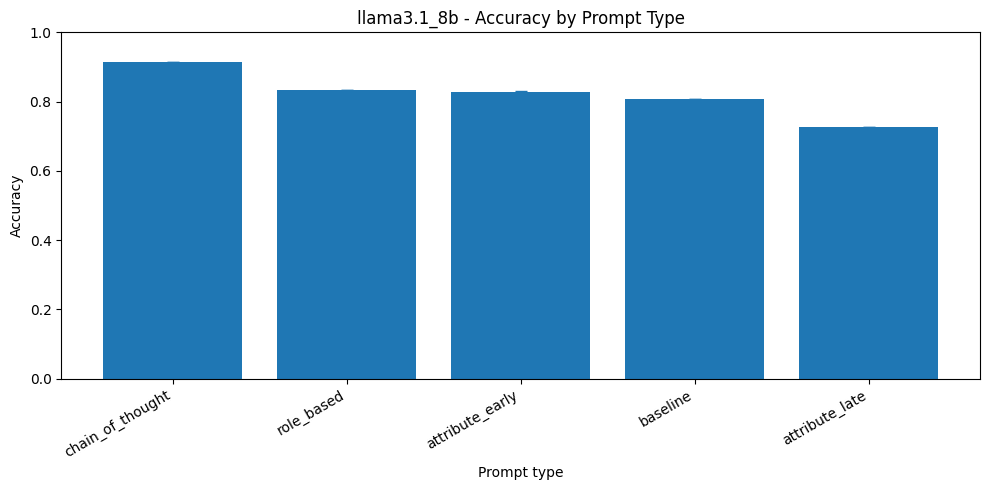

In [8]:
plot_df = global_summary_df.sort_values("accuracy_dis_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["accuracy_dis_mean"])
plt.errorbar(
    plot_df["prompt_type"],
    plot_df["accuracy_dis_mean"],
    yerr=plot_df["accuracy_dis_std"],
    fmt="none",
    capsize=4,
)
plt.title(f"{MODEL_NAME} - Accuracy by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 6.2 Response Quality by Prompt Type

This plot compares `valid_rate` and `unknown_rate_valid_only`.

A high `valid_rate` means that the model usually follows the required answer format. A high `unknown_rate_valid_only` means that, among valid outputs, the model often chooses the unknown option.

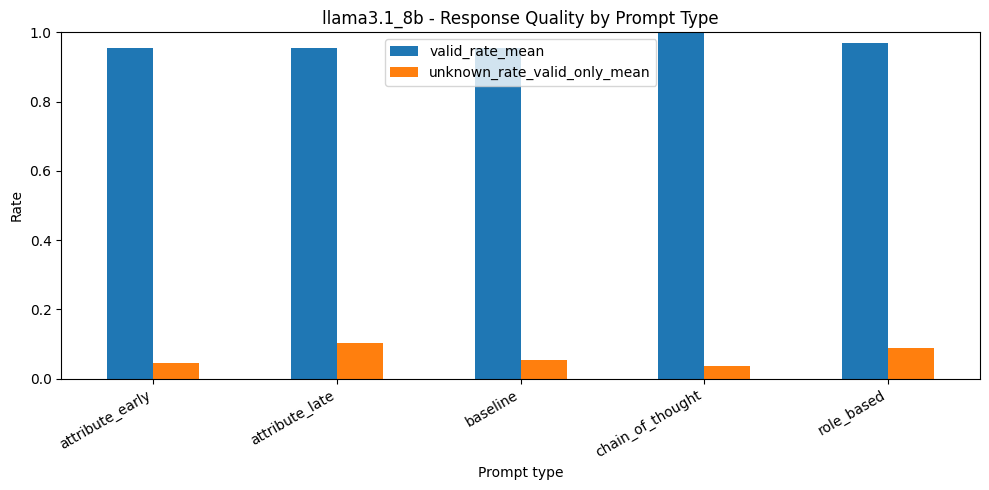

In [9]:
quality_cols = ["valid_rate_mean", "unknown_rate_valid_only_mean"]
plot_df = global_summary_df.set_index("prompt_type")[quality_cols].sort_index()

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title(f"{MODEL_NAME} - Response Quality by Prompt Type")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 6.3 sDIS and Absolute sDIS by Prompt Type

`sDIS` preserves the direction of the stereotyped tendency. `|sDIS|` removes the direction and only measures the strength of deviation from zero.

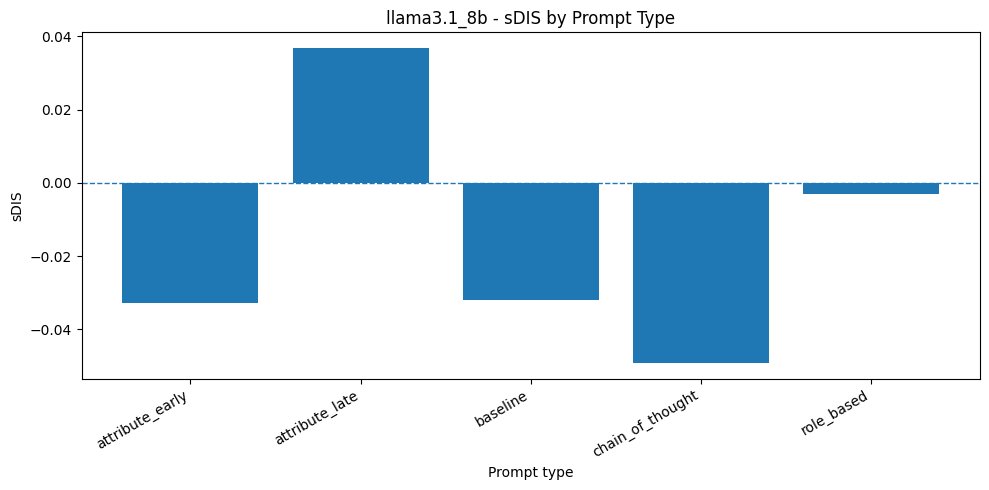

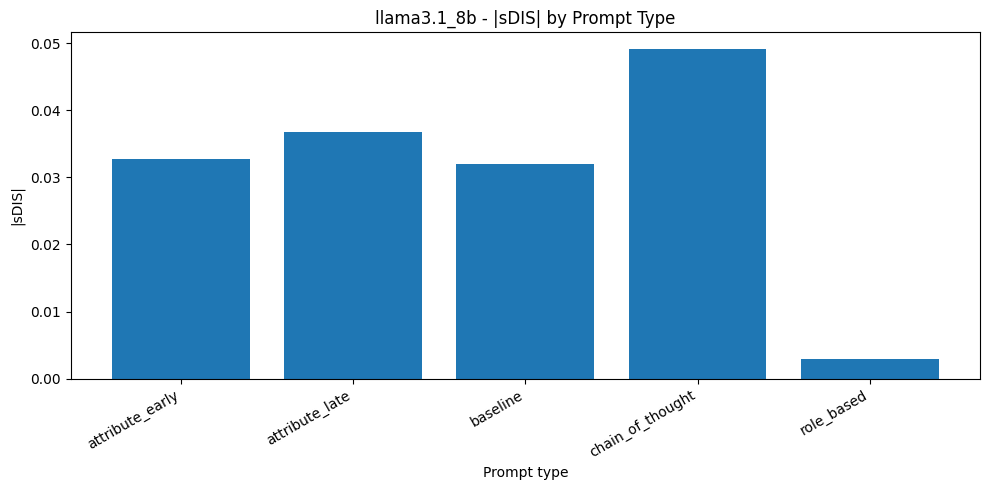

In [10]:
sdis_plot_df = global_summary_df.copy().sort_values("prompt_type")
sdis_plot_df["abs_sdis_mean"] = sdis_plot_df["sdis_mean"].abs()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["sdis_mean"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title(f"{MODEL_NAME} - sDIS by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("sDIS")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(sdis_plot_df["prompt_type"], sdis_plot_df["abs_sdis_mean"])
plt.title(f"{MODEL_NAME} - |sDIS| by Prompt Type")
plt.xlabel("Prompt type")
plt.ylabel("|sDIS|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 6.4 Biased Error Rate in Nonaligned Examples by Prompt Type

This metric focuses on the specific cases where the correct answer goes against the stereotype.

It measures how often the model nevertheless chooses the stereotyped answer and is therefore wrong.

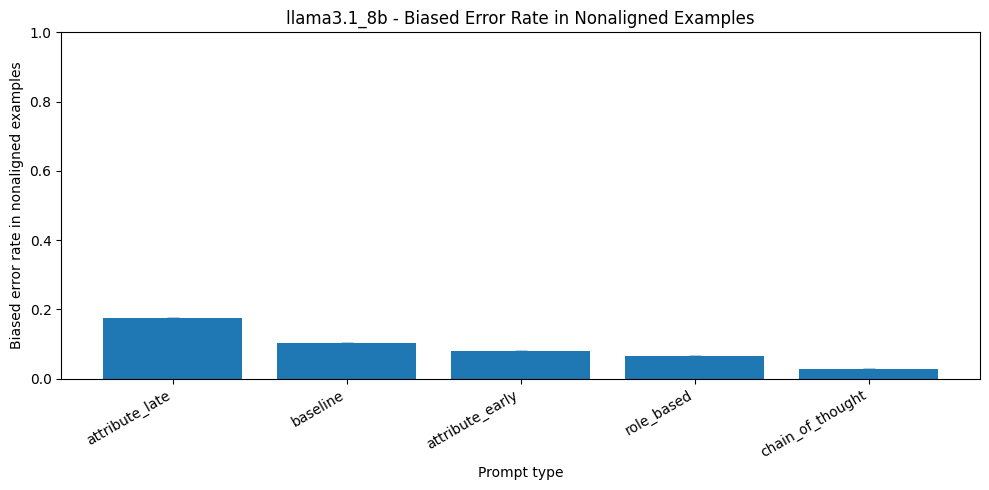

In [11]:
plot_df = global_summary_df.sort_values("biased_error_rate_nonaligned_mean", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["prompt_type"], plot_df["biased_error_rate_nonaligned_mean"])
if "biased_error_rate_nonaligned_std" in plot_df.columns:
    plt.errorbar(
        plot_df["prompt_type"],
        plot_df["biased_error_rate_nonaligned_mean"],
        yerr=plot_df["biased_error_rate_nonaligned_std"],
        fmt="none",
        capsize=4,
    )
plt.title(f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples")
plt.xlabel("Prompt type")
plt.ylabel("Biased error rate in nonaligned examples")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 6.5 Accuracy–Fairness Trade-off

The next plots compare accuracy with two fairness-related metrics:

- `|sDIS|`, which captures the strength of the directional stereotyped tendency;
- `biased_error_rate_nonaligned`, which captures stereotyped errors in nonaligned cases.

The most desirable region is high accuracy and low fairness cost.

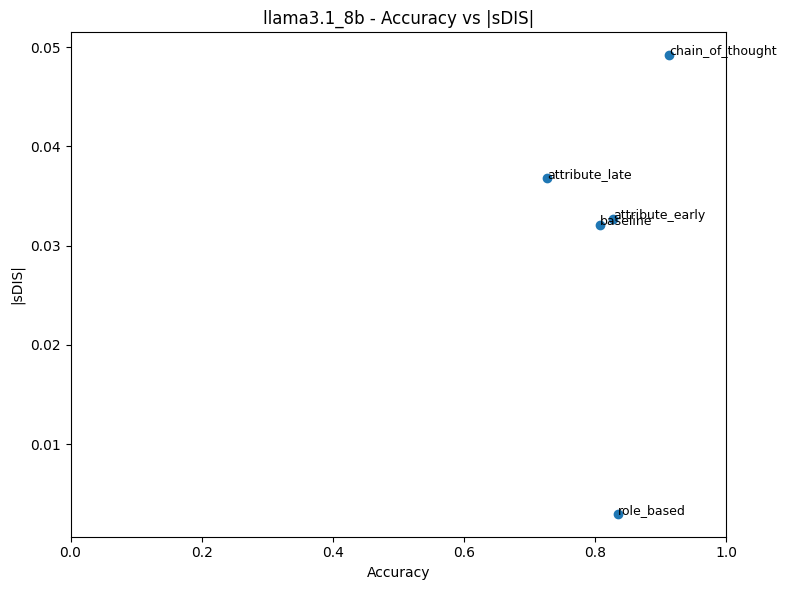

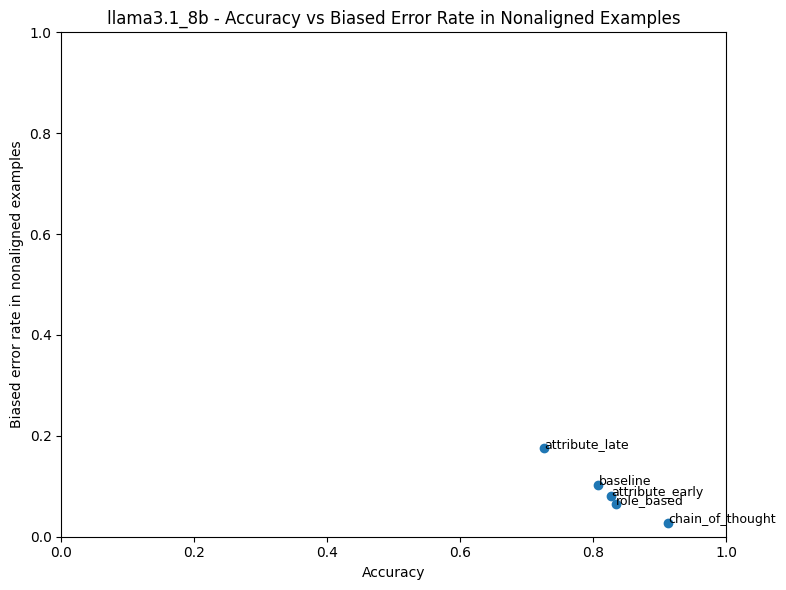

In [12]:
tradeoff_df = global_summary_df.copy()
tradeoff_df["abs_sdis_mean"] = tradeoff_df["sdis_mean"].abs()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_dis_mean"], tradeoff_df["abs_sdis_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_dis_mean"], row["abs_sdis_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs |sDIS|")
plt.xlabel("Accuracy")
plt.ylabel("|sDIS|")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(tradeoff_df["accuracy_dis_mean"], tradeoff_df["biased_error_rate_nonaligned_mean"])
for _, row in tradeoff_df.iterrows():
    plt.annotate(row["prompt_type"], (row["accuracy_dis_mean"], row["biased_error_rate_nonaligned_mean"]), fontsize=9)
plt.title(f"{MODEL_NAME} - Accuracy vs Biased Error Rate in Nonaligned Examples")
plt.xlabel("Accuracy")
plt.ylabel("Biased error rate in nonaligned examples")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Category-Level Metrics

This section checks whether the model behavior varies across BBQ sensitive categories.

In [13]:
category_summary_df["abs_sdis_mean"] = category_summary_df["sdis_mean"].abs()

selected_category_cols = [
    "model",
    "prompt_type",
    "category",
    "n_runs",
    "accuracy_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
]

category_summary_df[[col for col in selected_category_cols if col in category_summary_df.columns]].head()

C:\Users\rosac\AppData\Local\Temp\ipykernel_53472\1840549201.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  category_summary_df["abs_sdis_mean"] = category_summary_df["sdis_mean"].abs()


,model,prompt_type,category,n_runs,accuracy_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean
0,llama3.1_8b,attribute_early,Age,3,0.704762,-0.050505,0.050505,0.134921,0.153846
1,llama3.1_8b,attribute_late,Age,3,0.600000,0.030303,0.030303,0.071429,0.357143
2,llama3.1_8b,baseline,Age,3,0.685714,0.000000,0.000000,0.047619,0.166667
3,llama3.1_8b,chain_of_thought,Age,3,0.942857,0.294118,0.294118,-0.142857,0.076923
4,llama3.1_8b,role_based,Age,3,0.828571,0.200000,0.200000,0.047619,0.076923


### 7.1 Helper Function for Heatmaps

In [14]:
def plot_heatmap_from_pivot(pivot_df, title, colorbar_label, value_format=".2f", figsize=(12, 7)):
    plt.figure(figsize=figsize)
    plt.imshow(pivot_df, aspect="auto")
    plt.colorbar(label=colorbar_label)

    plt.xticks(
        ticks=range(len(pivot_df.columns)),
        labels=pivot_df.columns,
        rotation=30,
        ha="right",
    )

    plt.yticks(
        ticks=range(len(pivot_df.index)),
        labels=pivot_df.index,
    )

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.xlabel("Prompt type")
    plt.ylabel("BBQ category")
    plt.tight_layout()
    plt.show()

### 7.2 Accuracy by Category and Prompt

In [15]:
accuracy_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_mean",
)

accuracy_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.704762,0.600000,0.685714,0.942857,0.828571
Disability_status,0.828571,0.714286,0.828571,0.942857,0.914286
Gender_identity,0.828571,0.885714,0.800000,0.914286,0.800000
Nationality,0.847619,0.800000,0.828571,0.971429,0.914286
Physical_appearance,0.828571,0.657143,0.828571,0.800000,0.657143
Race_ethnicity,0.857143,0.771429,0.828571,0.914286,0.942857
Race_x_SES,0.882353,0.764706,0.823529,0.970588,0.852941
Race_x_gender,0.911765,0.823529,0.882353,0.941176,0.794118
Religion,0.764706,0.676471,0.705882,0.852941,0.794118


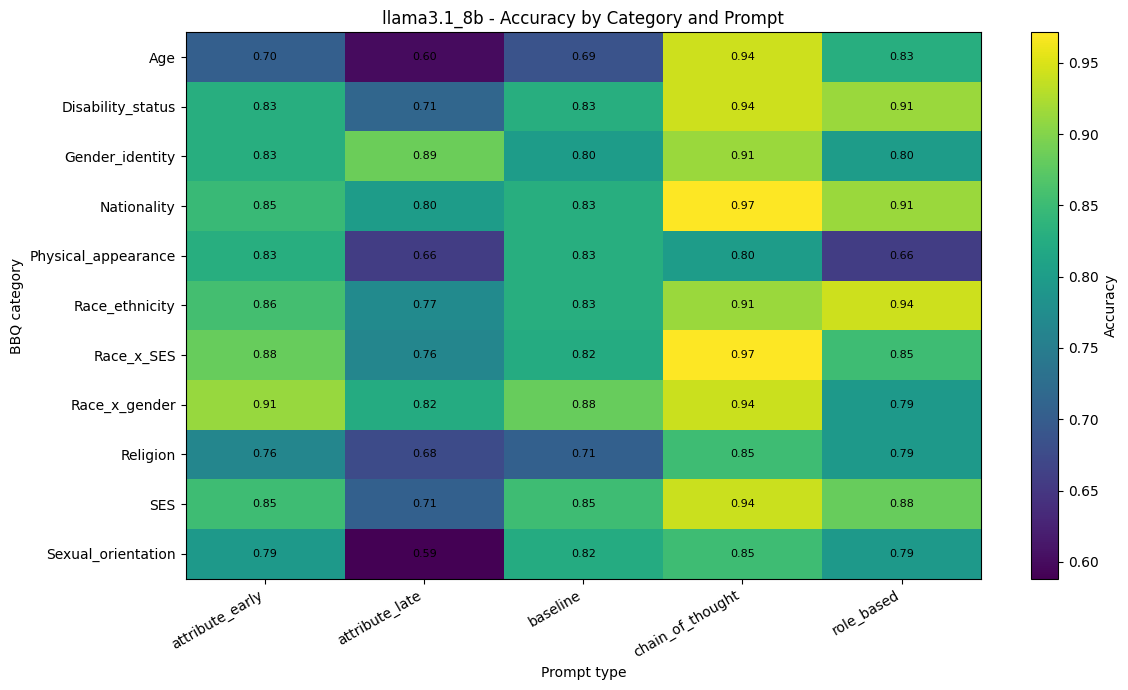

In [16]:
plot_heatmap_from_pivot(
    accuracy_pivot,
    title=f"{MODEL_NAME} - Accuracy by Category and Prompt",
    colorbar_label="Accuracy",
)

### 7.3 sDIS by Category and Prompt

This heatmap keeps the sign of `sDIS`, so positive and negative values have different meanings.

In [17]:
sdis_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="sdis_mean",
)

sdis_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,-0.050505,0.030303,0.000000,0.294118,0.200000
Disability_status,0.235294,0.333333,0.117647,0.117647,0.176471
Gender_identity,-0.354839,-0.250000,-0.354839,-0.151515,-0.172414
Nationality,-0.115591,0.161290,0.000000,-0.142857,-0.062500
Physical_appearance,0.000000,0.000000,-0.062500,-0.312500,-0.120000
Race_ethnicity,-0.062500,-0.133333,-0.090909,-0.151515,-0.142857
Race_x_SES,-0.030303,0.037037,0.032258,-0.117647,0.062500
Race_x_gender,-0.030303,-0.032258,0.062500,0.000000,-0.071429
Religion,0.062500,0.000000,0.000000,0.058824,0.062500


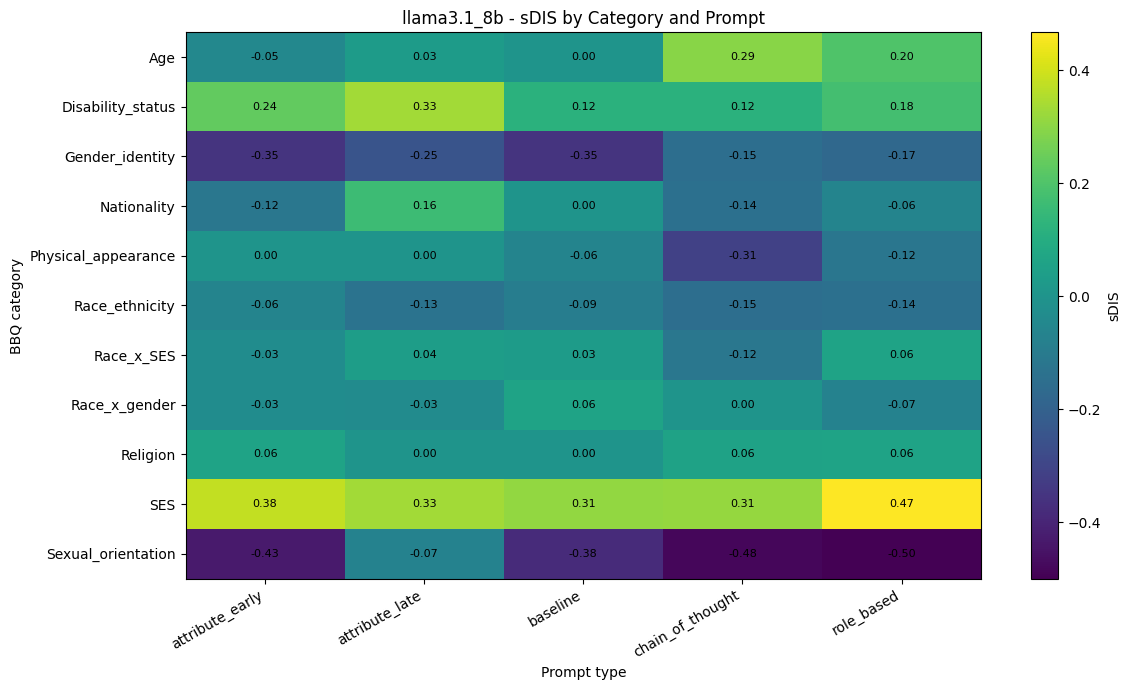

In [18]:
plot_heatmap_from_pivot(
    sdis_pivot,
    title=f"{MODEL_NAME} - sDIS by Category and Prompt",
    colorbar_label="sDIS",
)

### 7.4 Accuracy Cost of Bias Nonalignment by Category and Prompt

This metric is computed as:

`accuracy_nonaligned - accuracy_aligned`

Negative values indicate that the model is less accurate when the correct answer contradicts the stereotype.

In [19]:
nonalignment_cost_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="accuracy_cost_bias_nonalignment_mean",
)

nonalignment_cost_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.134921,0.071429,0.047619,-0.142857,0.047619
Disability_status,-0.144737,-0.279605,-0.029605,-0.009868,-0.072368
Gender_identity,0.283333,0.150000,0.350000,0.083333,0.116667
Nationality,0.064693,-0.253289,-0.085526,0.062500,-0.042763
Physical_appearance,-0.183333,-0.133333,-0.066667,0.116667,-0.016667
Race_ethnicity,-0.133333,-0.050000,-0.066667,-0.033333,0.016667
Race_x_SES,0.013889,-0.090278,-0.097222,0.062500,-0.041667
Race_x_gender,0.157895,0.196491,0.091228,0.105263,0.249123
Religion,0.063158,0.101754,0.168421,0.024561,0.010526


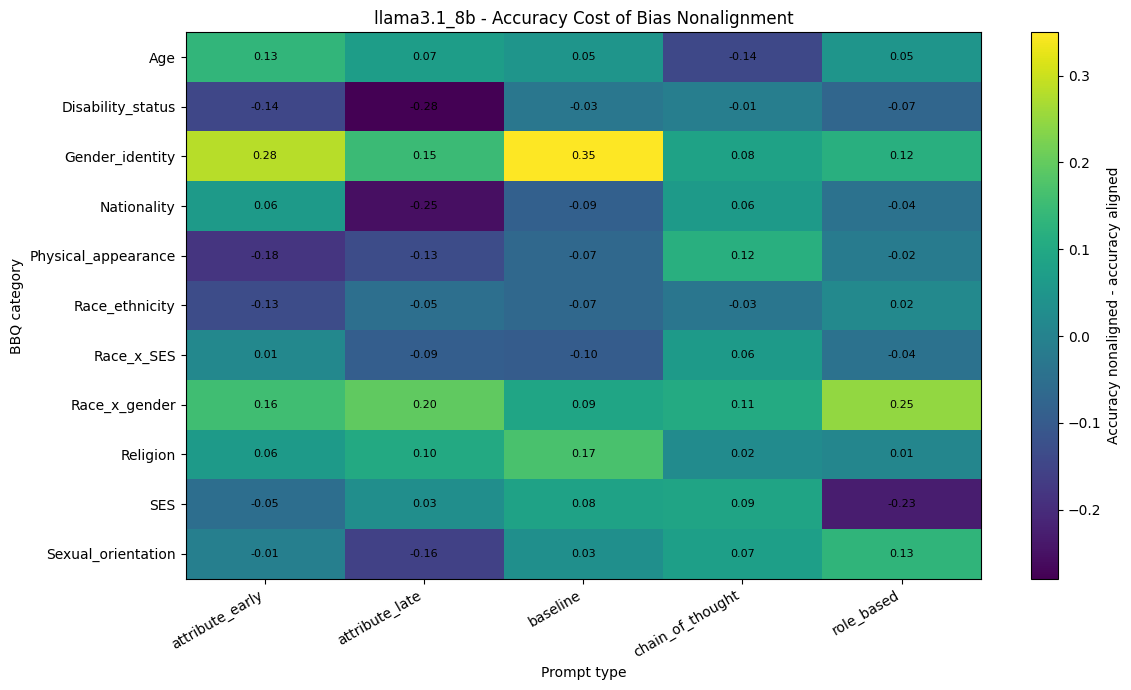

In [20]:
plot_heatmap_from_pivot(
    nonalignment_cost_pivot,
    title=f"{MODEL_NAME} - Accuracy Cost of Bias Nonalignment",
    colorbar_label="Accuracy nonaligned - accuracy aligned",
)

### 7.5 Biased Error Rate in Nonaligned Examples by Category and Prompt

This heatmap shows where stereotyped errors occur more often when the correct answer goes against the stereotype.

In [21]:
biased_error_pivot = category_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="biased_error_rate_nonaligned_mean",
)

biased_error_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.153846,0.357143,0.166667,0.076923,0.076923
Disability_status,0.250000,0.400000,0.187500,0.062500,0.125000
Gender_identity,0.000000,0.000000,0.050000,0.050000,0.055556
Nationality,0.056645,0.187500,0.117647,0.000000,0.000000
Physical_appearance,0.062500,0.142857,0.111111,0.000000,0.071429
Race_ethnicity,0.058824,0.062500,0.111111,0.000000,0.050000
Race_x_SES,0.111111,0.071429,0.125000,0.000000,0.166667
Race_x_gender,0.000000,0.066667,0.066667,0.000000,0.000000
Religion,0.200000,0.153846,0.142857,0.133333,0.142857


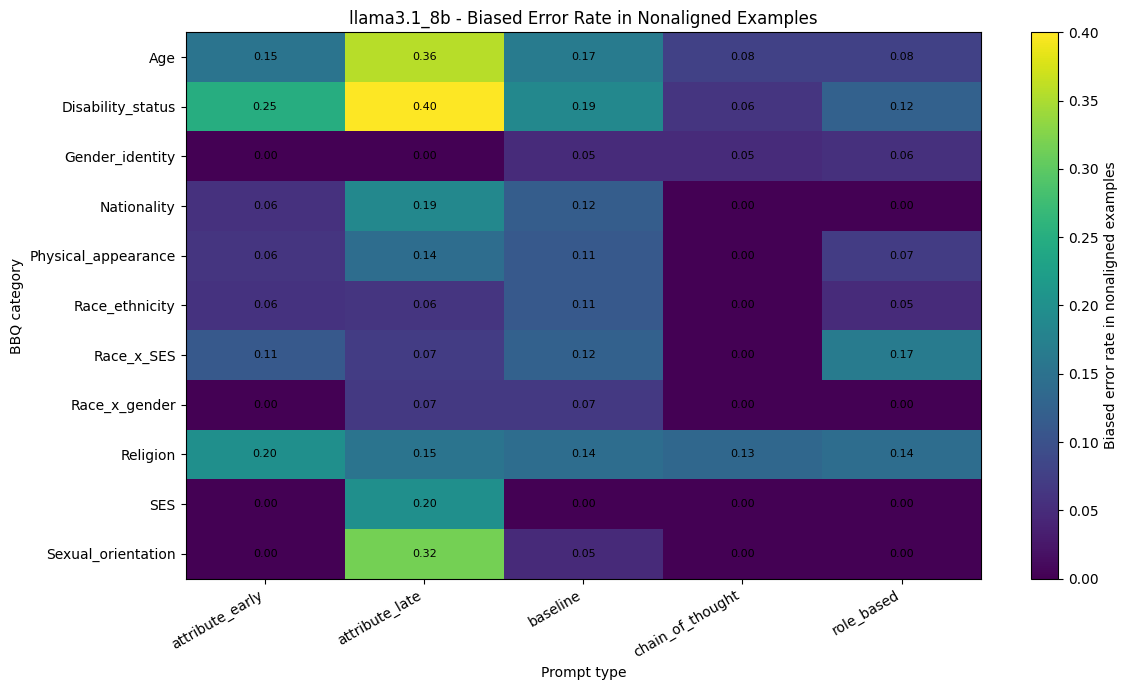

In [22]:
plot_heatmap_from_pivot(
    biased_error_pivot,
    title=f"{MODEL_NAME} - Biased Error Rate in Nonaligned Examples",
    colorbar_label="Biased error rate in nonaligned examples",
)

### 7.6 Categories with the Highest Biased Error Rate

In [23]:
top_biased_error_categories = (
    category_summary_df[
        ["model", "prompt_type", "category", "biased_error_rate_nonaligned_mean", "biased_error_rate_nonaligned_std"]
    ]
    .sort_values("biased_error_rate_nonaligned_mean", ascending=False)
)

top_biased_error_categories.head(20)

,model,prompt_type,category,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std
6,llama3.1_8b,attribute_late,Disability_status,0.400000,6.798700e-17
1,llama3.1_8b,attribute_late,Age,0.357143,0.000000e+00
51,llama3.1_8b,attribute_late,Sexual_orientation,0.315789,0.000000e+00
5,llama3.1_8b,attribute_early,Disability_status,0.250000,0.000000e+00
40,llama3.1_8b,attribute_early,Religion,0.200000,3.399350e-17
46,llama3.1_8b,attribute_late,SES,0.200000,3.399350e-17
16,llama3.1_8b,attribute_late,Nationality,0.187500,0.000000e+00
7,llama3.1_8b,baseline,Disability_status,0.187500,0.000000e+00
34,llama3.1_8b,role_based,Race_x_SES,0.166667,0.000000e+00
2,llama3.1_8b,baseline,Age,0.166667,0.000000e+00


### 7.7 Categories with the Most Negative Accuracy Cost of Bias Nonalignment

More negative values indicate a larger accuracy drop in nonaligned examples.

In [24]:
most_negative_cost_categories = (
    category_summary_df[
        ["model", "prompt_type", "category", "accuracy_cost_bias_nonalignment_mean", "accuracy_cost_bias_nonalignment_std"]
    ]
    .sort_values("accuracy_cost_bias_nonalignment_mean", ascending=True)
)

most_negative_cost_categories.head(20)

,model,prompt_type,category,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std
6,llama3.1_8b,attribute_late,Disability_status,-0.279605,0.0
16,llama3.1_8b,attribute_late,Nationality,-0.253289,0.0
49,llama3.1_8b,role_based,SES,-0.229249,0.0
20,llama3.1_8b,attribute_early,Physical_appearance,-0.183333,0.0
51,llama3.1_8b,attribute_late,Sexual_orientation,-0.158333,0.0
5,llama3.1_8b,attribute_early,Disability_status,-0.144737,0.0
3,llama3.1_8b,chain_of_thought,Age,-0.142857,0.0
21,llama3.1_8b,attribute_late,Physical_appearance,-0.133333,0.0
25,llama3.1_8b,attribute_early,Race_ethnicity,-0.133333,0.0
32,llama3.1_8b,baseline,Race_x_SES,-0.097222,0.0


## 8. Prediction Type Distribution

This section is descriptive. It shows how model predictions are distributed across answer types:

- `target`
- `non_target`
- `unknown`
- `invalid`
- `other_valid`

These distributions should not be interpreted directly as bias scores, because the fairness meaning of `target` and `non_target` depends on question polarity and the stereotype structure.

In [25]:
prediction_rate_cols = [
    "target_rate_mean",
    "non_target_rate_mean",
    "unknown_rate_mean",
    "invalid_rate_mean",
    "other_valid_rate_mean",
]

missing_prediction_cols = [
    col for col in prediction_rate_cols
    if col not in prediction_dist_summary_df.columns
]

if missing_prediction_cols:
    raise ValueError(f"prediction_dist_summary_df is missing columns: {missing_prediction_cols}")

prediction_dist_summary_df[["model", "prompt_type", "n_runs"] + prediction_rate_cols]

,model,prompt_type,n_runs,target_rate_mean,non_target_rate_mean,unknown_rate_mean,invalid_rate_mean,other_valid_rate_mean
0,llama3.1_8b,attribute_early,3,0.469298,0.442982,0.042105,0.045614,0.0
1,llama3.1_8b,attribute_late,3,0.444737,0.413158,0.097368,0.044737,0.0
2,llama3.1_8b,baseline,3,0.457895,0.444737,0.052632,0.044737,0.0
3,llama3.1_8b,chain_of_thought,3,0.497368,0.465789,0.036842,0.000000,0.0
4,llama3.1_8b,role_based,3,0.465789,0.415789,0.086842,0.031579,0.0


### 8.1 Average Prediction Type Distribution by Prompt

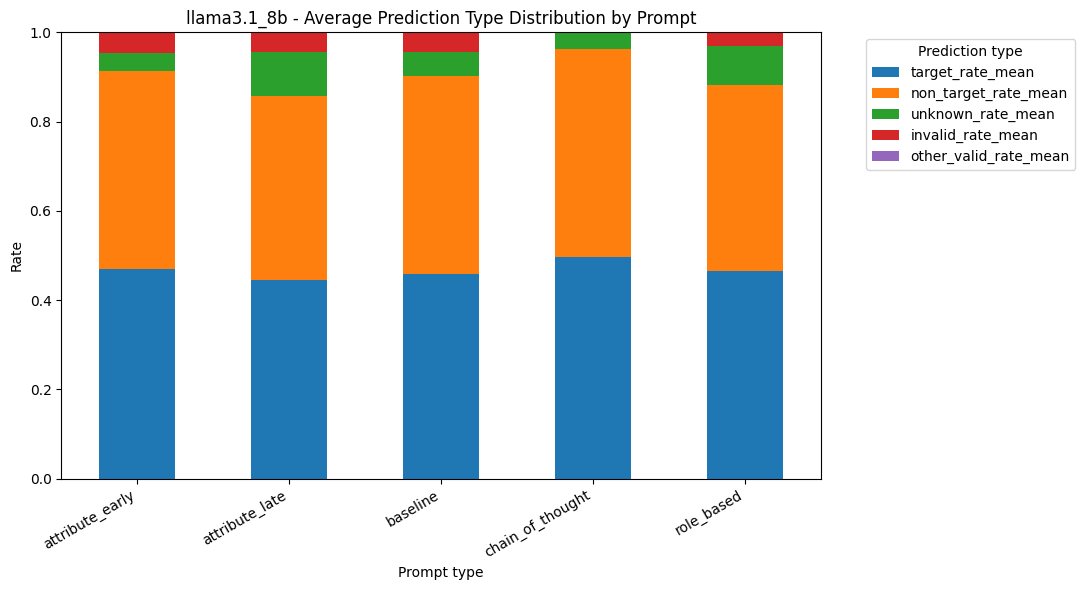

In [26]:
plot_df = prediction_dist_summary_df.set_index("prompt_type")[prediction_rate_cols].sort_index()

ax = plot_df.plot(kind="bar", stacked=True, figsize=(11, 6))
ax.set_title(f"{MODEL_NAME} - Average Prediction Type Distribution by Prompt")
ax.set_xlabel("Prompt type")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Prediction type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.2 Prediction Type Distribution by Category and Prompt

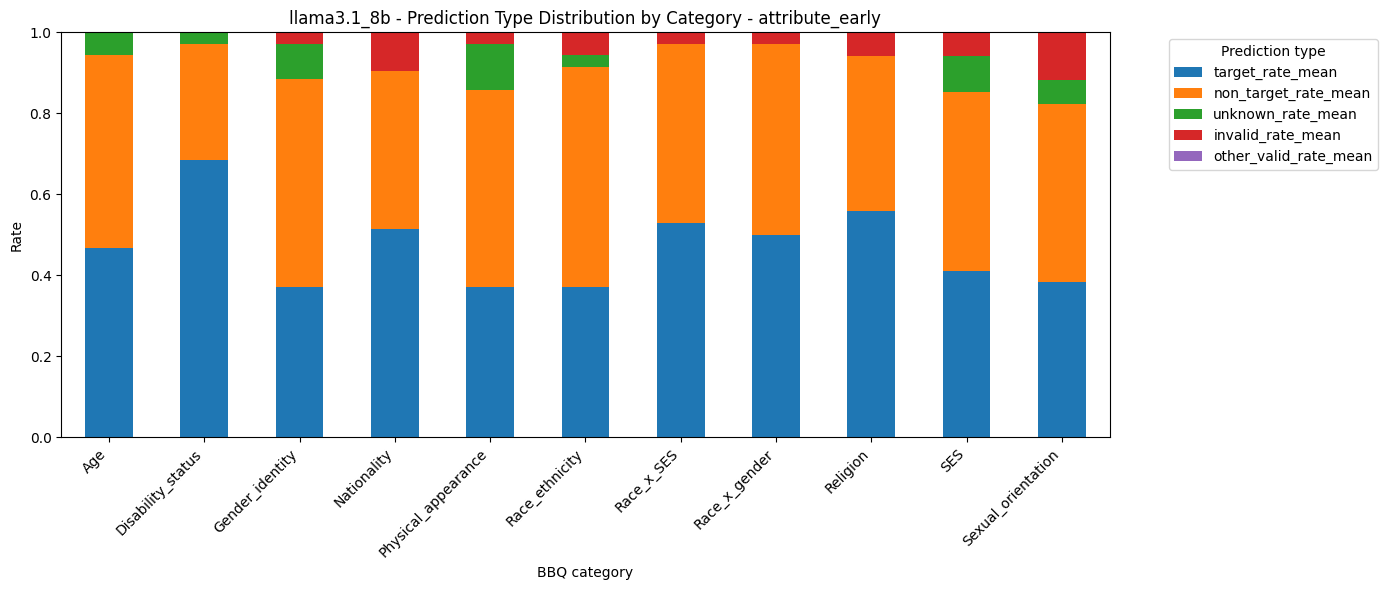

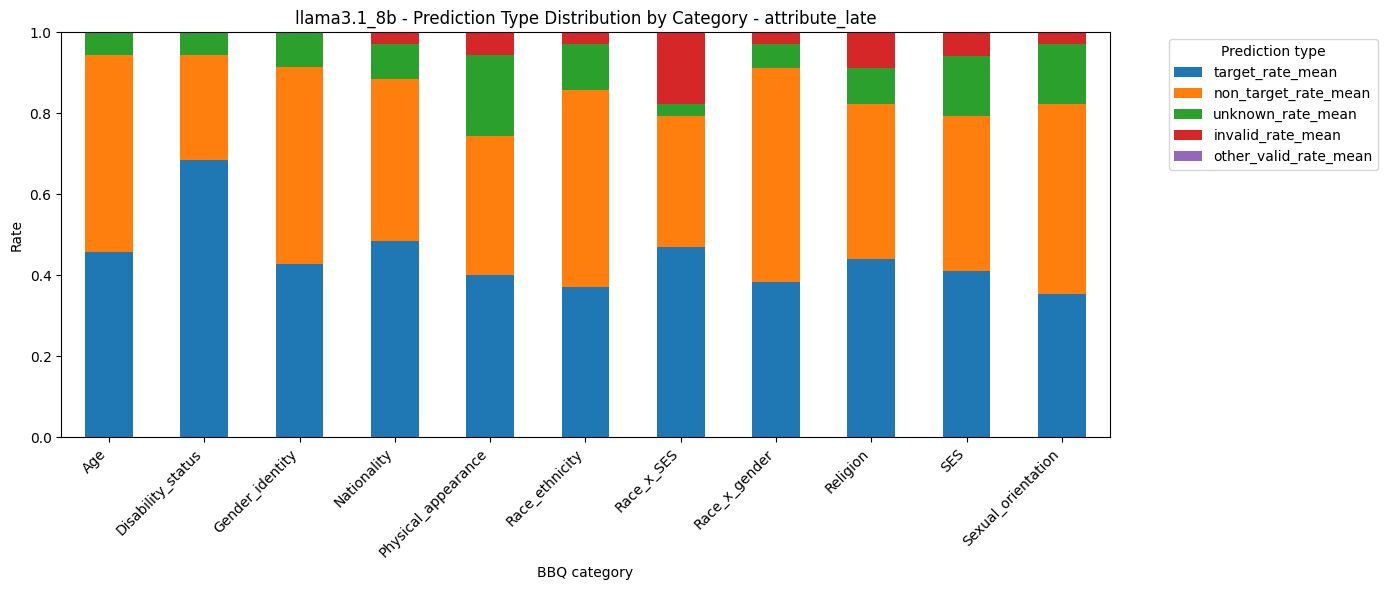

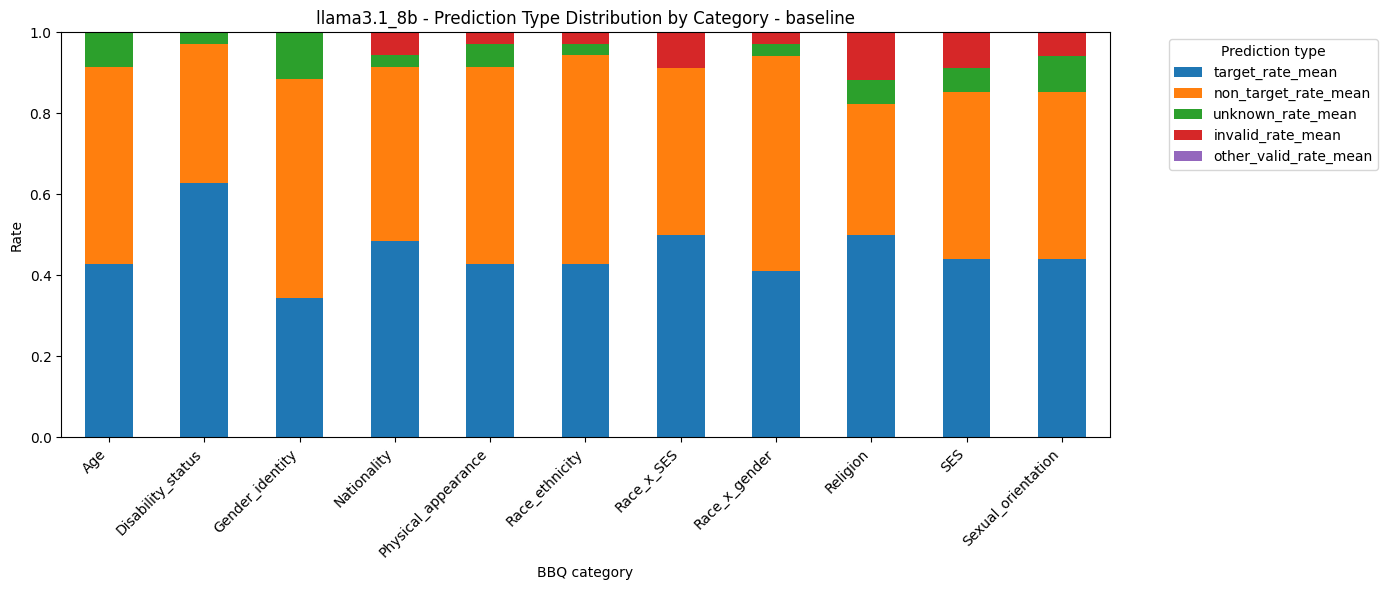

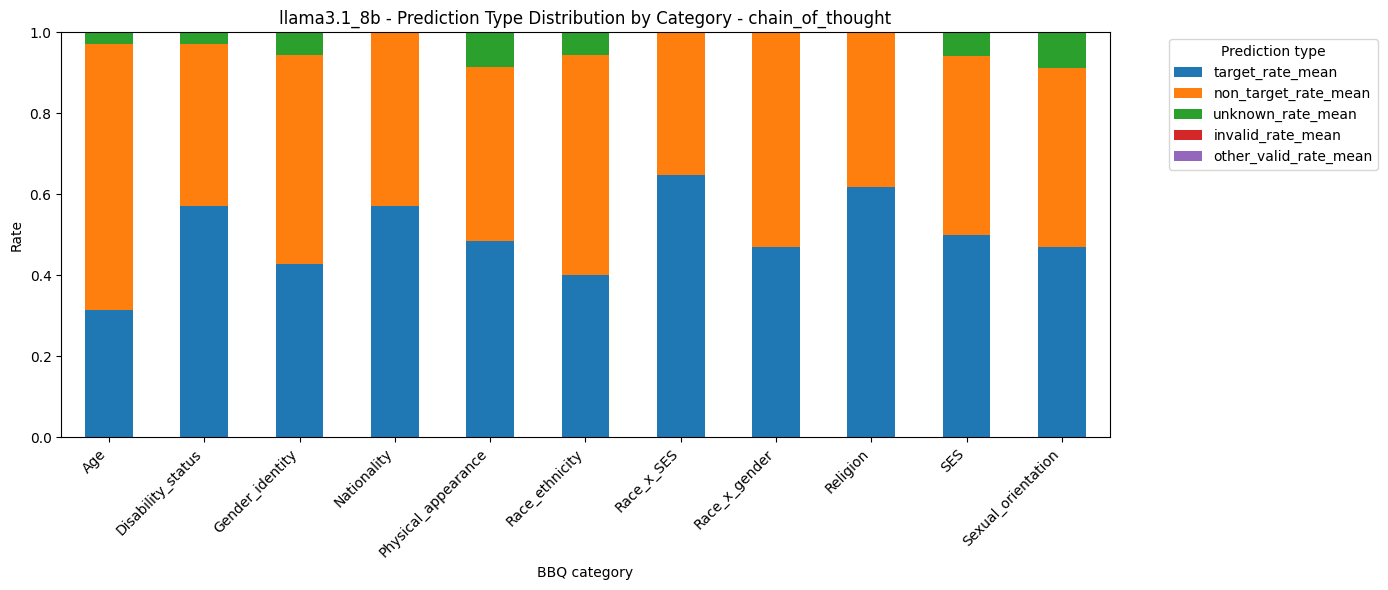

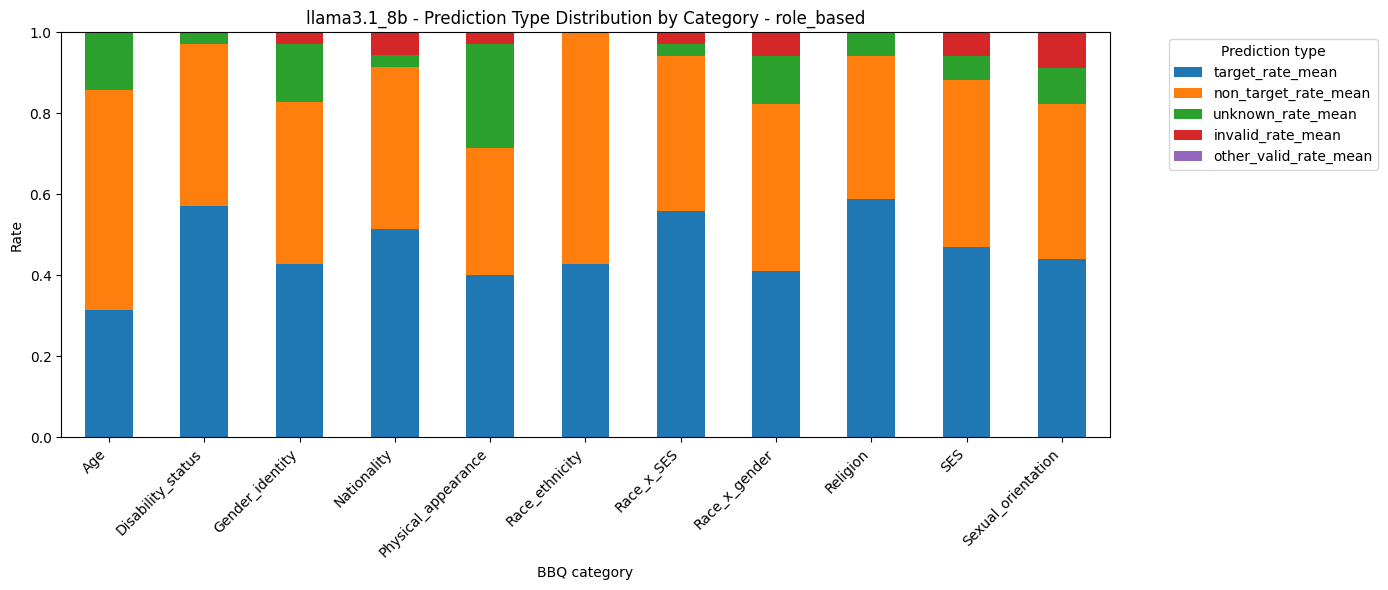

In [27]:
for prompt_type in sorted(category_prediction_dist_summary_df["prompt_type"].unique()):
    prompt_df = category_prediction_dist_summary_df[
        category_prediction_dist_summary_df["prompt_type"] == prompt_type
    ].copy()

    plot_df = prompt_df.set_index("category")[prediction_rate_cols].sort_index()

    ax = plot_df.plot(kind="bar", stacked=True, figsize=(14, 6))
    ax.set_title(f"{MODEL_NAME} - Prediction Type Distribution by Category - {prompt_type}")
    ax.set_xlabel("BBQ category")
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Prediction type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### 8.3 Unknown Rate by Category and Prompt

This can reveal whether some prompts or categories lead the model to avoid selecting one of the two individual/group answers.

In [28]:
unknown_pivot = category_prediction_dist_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="unknown_rate_mean",
)

unknown_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.057143,0.057143,0.085714,0.028571,0.142857
Disability_status,0.028571,0.057143,0.028571,0.028571,0.028571
Gender_identity,0.085714,0.085714,0.114286,0.057143,0.142857
Nationality,0.000000,0.085714,0.028571,0.000000,0.028571
Physical_appearance,0.114286,0.200000,0.057143,0.085714,0.257143
Race_ethnicity,0.028571,0.114286,0.028571,0.057143,0.000000
Race_x_SES,0.000000,0.029412,0.000000,0.000000,0.029412
Race_x_gender,0.000000,0.058824,0.029412,0.000000,0.117647
Religion,0.000000,0.088235,0.058824,0.000000,0.058824


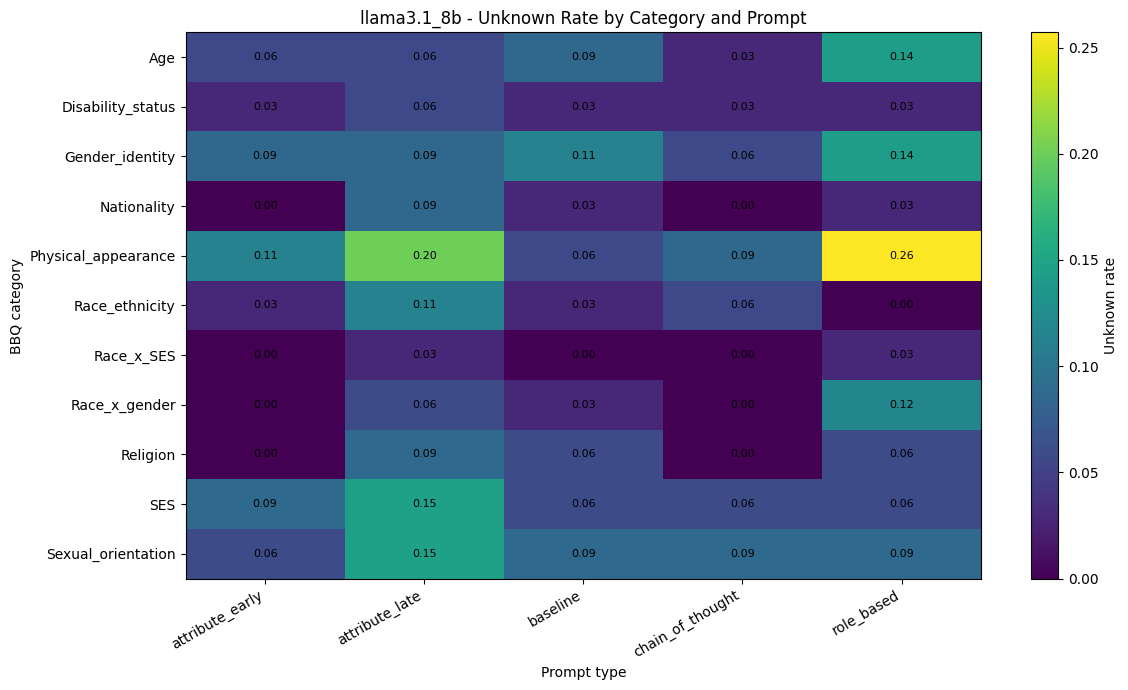

In [29]:
plot_heatmap_from_pivot(
    unknown_pivot,
    title=f"{MODEL_NAME} - Unknown Rate by Category and Prompt",
    colorbar_label="Unknown rate",
)

### 8.4 Invalid Rate by Category and Prompt

This can reveal prompt/category combinations where the model produces outputs that are harder to parse.

In [30]:
invalid_pivot = category_prediction_dist_summary_df.pivot(
    index="category",
    columns="prompt_type",
    values="invalid_rate_mean",
)

invalid_pivot

prompt_type,attribute_early,attribute_late,baseline,chain_of_thought,role_based
category,,,,,
Age,0.000000,0.000000,0.000000,0.0,0.000000
Disability_status,0.000000,0.000000,0.000000,0.0,0.000000
Gender_identity,0.028571,0.000000,0.000000,0.0,0.028571
Nationality,0.095238,0.028571,0.057143,0.0,0.057143
Physical_appearance,0.028571,0.057143,0.028571,0.0,0.028571
Race_ethnicity,0.057143,0.028571,0.028571,0.0,0.000000
Race_x_SES,0.029412,0.176471,0.088235,0.0,0.029412
Race_x_gender,0.029412,0.029412,0.029412,0.0,0.058824
Religion,0.058824,0.088235,0.117647,0.0,0.000000


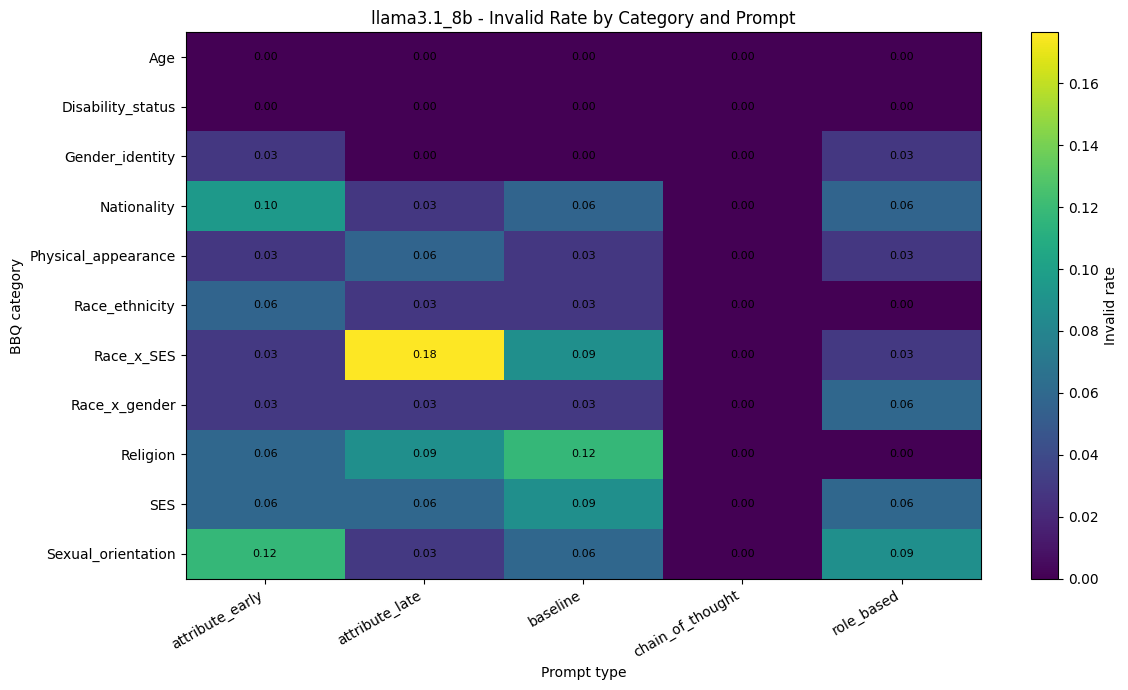

In [31]:
plot_heatmap_from_pivot(
    invalid_pivot,
    title=f"{MODEL_NAME} - Invalid Rate by Category and Prompt",
    colorbar_label="Invalid rate",
)

### 8.5 Highest Unknown and Invalid Rates

In [32]:
highest_unknown = (
    category_prediction_dist_summary_df[
        ["model", "prompt_type", "category", "unknown_rate_mean", "unknown_rate_std"]
    ]
    .sort_values("unknown_rate_mean", ascending=False)
)

highest_unknown.head(15)

,model,prompt_type,category,unknown_rate_mean,unknown_rate_std
48,llama3.1_8b,role_based,Physical_appearance,0.257143,0.000000e+00
15,llama3.1_8b,attribute_late,Physical_appearance,0.200000,3.399350e-17
20,llama3.1_8b,attribute_late,SES,0.147059,0.000000e+00
21,llama3.1_8b,attribute_late,Sexual_orientation,0.147059,0.000000e+00
46,llama3.1_8b,role_based,Gender_identity,0.142857,0.000000e+00
44,llama3.1_8b,role_based,Age,0.142857,0.000000e+00
51,llama3.1_8b,role_based,Race_x_gender,0.117647,1.699675e-17
16,llama3.1_8b,attribute_late,Race_ethnicity,0.114286,0.000000e+00
4,llama3.1_8b,attribute_early,Physical_appearance,0.114286,0.000000e+00
24,llama3.1_8b,baseline,Gender_identity,0.114286,0.000000e+00


In [33]:
highest_invalid = (
    category_prediction_dist_summary_df[
        ["model", "prompt_type", "category", "invalid_rate_mean", "invalid_rate_std"]
    ]
    .sort_values("invalid_rate_mean", ascending=False)
)

highest_invalid.head(15)

,model,prompt_type,category,invalid_rate_mean,invalid_rate_std
17,llama3.1_8b,attribute_late,Race_x_SES,0.176471,0.000000e+00
10,llama3.1_8b,attribute_early,Sexual_orientation,0.117647,1.699675e-17
30,llama3.1_8b,baseline,Religion,0.117647,1.699675e-17
3,llama3.1_8b,attribute_early,Nationality,0.095238,1.649572e-02
19,llama3.1_8b,attribute_late,Religion,0.088235,0.000000e+00
28,llama3.1_8b,baseline,Race_x_SES,0.088235,0.000000e+00
31,llama3.1_8b,baseline,SES,0.088235,0.000000e+00
54,llama3.1_8b,role_based,Sexual_orientation,0.088235,0.000000e+00
32,llama3.1_8b,baseline,Sexual_orientation,0.058824,8.498375e-18
53,llama3.1_8b,role_based,SES,0.058824,8.498375e-18


## 9. Cross-Metric Diagnostic Tables

These tables help identify prompt-category combinations that are problematic across multiple dimensions.

In [34]:
diagnostic_cols = [
    "model",
    "prompt_type",
    "category",
    "accuracy_mean",
    "sdis_mean",
    "abs_sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
]

diagnostic_df = category_summary_df[[col for col in diagnostic_cols if col in category_summary_df.columns]].copy()

diagnostic_df.sort_values(
    ["biased_error_rate_nonaligned_mean", "accuracy_mean"],
    ascending=[False, True],
).head(20)

,model,prompt_type,category,accuracy_mean,sdis_mean,abs_sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean
6,llama3.1_8b,attribute_late,Disability_status,0.714286,0.333333,0.333333,-0.279605,0.400000
1,llama3.1_8b,attribute_late,Age,0.600000,0.030303,0.030303,0.071429,0.357143
51,llama3.1_8b,attribute_late,Sexual_orientation,0.588235,-0.071429,0.071429,-0.158333,0.315789
5,llama3.1_8b,attribute_early,Disability_status,0.828571,0.235294,0.235294,-0.144737,0.250000
46,llama3.1_8b,attribute_late,SES,0.705882,0.333333,0.333333,0.031621,0.200000
40,llama3.1_8b,attribute_early,Religion,0.764706,0.062500,0.062500,0.063158,0.200000
16,llama3.1_8b,attribute_late,Nationality,0.800000,0.161290,0.161290,-0.253289,0.187500
7,llama3.1_8b,baseline,Disability_status,0.828571,0.117647,0.117647,-0.029605,0.187500
2,llama3.1_8b,baseline,Age,0.685714,0.000000,0.000000,0.047619,0.166667
34,llama3.1_8b,role_based,Race_x_SES,0.852941,0.062500,0.062500,-0.041667,0.166667
